# Basic MIMO Simulations
In this notebook, you will learn how to setup simulations of MIMO transmissions over
a flat-fading channel.

Here is a schematic diagram of the system model with all required components:

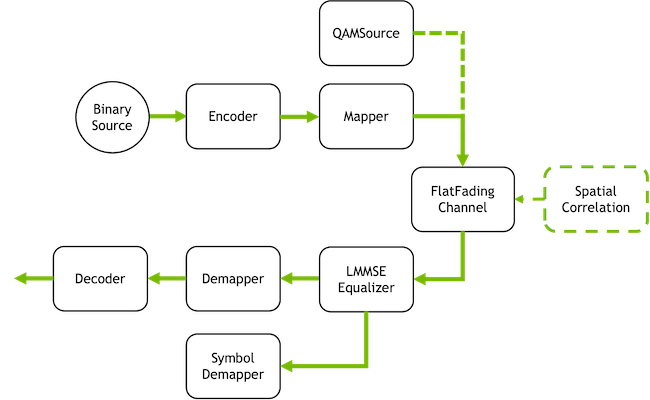

You will learn how to:

* Use the FastFadingChannel class
* Apply spatial antenna correlation
* Implement LMMSE detection with perfect channel knowledge
* Run BER/SER simulations

We will first walk through the configuration of all components of the system model, before building an end-to-end model which will allow you to run efficiently simulations with different parameter settings.

## Table of Contents
* [Configuration and Imports](#Configuration-and-Imports)
* [Simple uncoded transmission](#Simple-uncoded-transmission)
    * [Adding spatial correlation](#Adding-spatial-correlation)
* [Extension to channel coding](#Extension-to-channel-coding)
    * [BER simulations using a Sionna Block](#BER-simulations-using-a-Sionna-Block)

### Configuration and Imports

In [1]:
import os

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Set random seed for reproducability
sionna.phy.config.seed = 42

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from sionna.phy import Block
from sionna.phy.utils import ebnodb2no, compute_ser, compute_ber, PlotBER
from sionna.phy.channel import FlatFadingChannel, KroneckerModel
from sionna.phy.channel.utils import exp_corr_mat
from sionna.phy.mimo import lmmse_equalizer
from sionna.phy.mapping import SymbolDemapper, Mapper, Demapper, BinarySource, QAMSource
from sionna.phy.fec.ldpc.encoding import LDPC5GEncoder
from sionna.phy.fec.ldpc.decoding import LDPC5GDecoder

## Simple uncoded transmission

We will consider point-to-point transmissions from a transmitter with `num_tx_ant` antennas to a receiver
with `num_rx_ant` antennas. The transmitter applies no precoding and sends independent data stream from each antenna.

Let us now generate a batch of random transmit vectors of random 16QAM symbols:

In [3]:
num_tx_ant = 4
num_rx_ant = 16
num_bits_per_symbol = 4
batch_size = 1024
qam_source = QAMSource(num_bits_per_symbol)
x = qam_source([batch_size, num_tx_ant])
print(x.shape)

torch.Size([1024, 4])


Next, we will create an instance of the `FlatFadingChannel` class to simulate transmissions over
an i.i.d. Rayleigh fading channel. The channel will also add AWGN with variance `no`.
As we will need knowledge of the channel realizations for detection, we activate the `return_channel` flag.

In [4]:
channel = FlatFadingChannel(num_tx_ant, num_rx_ant, add_awgn=True, return_channel=True)
no = 0.2 # Noise variance of the channel

# y and h are the channel output and channel realizations, respectively.
y, h = channel(x, no)
print(y.shape)
print(h.shape)

torch.Size([1024, 16])
torch.Size([1024, 16, 4])


Using the perfect channel knowledge, we can now implement an LMMSE equalizer to compute soft-symbols.
The noise covariance matrix in this example is just a scaled identity matrix which we need to provide to the
`lmmse_equalizer`.

In [5]:
s = (no * torch.eye(num_rx_ant, num_rx_ant, dtype=y.dtype, device=y.device))
x_hat, no_eff = lmmse_equalizer(y, h, s)

Let us know have a look at the transmitted and received constellations:

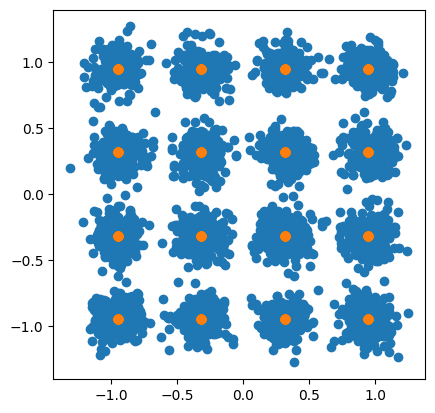

In [6]:
plt.axes().set_aspect(1.0)
plt.scatter(np.real(x_hat.cpu()), np.imag(x_hat.cpu()));
plt.scatter(np.real(x.cpu()), np.imag(x.cpu()));

As expected, the soft symbols `x_hat` are scattered around the 16QAM constellation points.
The equalizer output `no_eff` provides an estimate of the effective noise variance for each soft-symbol.

In [7]:
print(no_eff.shape)

torch.Size([1024, 4])


One can confirm that this estimate is correct by comparing the MSE between the transmitted and equalized symbols against the average estimated effective noise variance:

In [8]:
noise_var_eff = np.var((x-x_hat).cpu().numpy())
noise_var_est = np.mean(no_eff.cpu().numpy())
print(noise_var_eff)
print(noise_var_est)

0.016787495
0.016619638


The last step is to make hard decisions on the symbols and compute the SER:

In [9]:
symbol_demapper = SymbolDemapper("qam", num_bits_per_symbol, hard_out=True)

# Convert no to a tensor on the same device as x
no_tensor = torch.tensor(no, device=x.device)

# Get symbol indices for the transmitted symbols
x_ind = symbol_demapper(x, no_tensor)

# Get symbol indices for the received soft-symbols
x_ind_hat = symbol_demapper(x_hat, no_tensor)

compute_ser(x_ind, x_ind_hat)

tensor(0.0032, device='cuda:0', dtype=torch.float64)

### Adding spatial correlation

It is very easy add spatial correlation to the `FlatFadingChannel` using the `SpatialCorrelation` class.
We can, e.g., easily setup a Kronecker (`KroneckerModel`) (or two-sided) correlation model using exponetial correlation matrices (`exp_corr_mat`).

In [10]:
# Create transmit and receive correlation matrices
r_tx = exp_corr_mat(0.4, num_tx_ant)
r_rx = exp_corr_mat(0.9, num_rx_ant)

# Add the spatial correlation model to the channel
channel.spatial_corr = KroneckerModel(r_tx, r_rx)

Next, we can validate that the channel model applies the desired spatial correlation by creating a large batch of channel realizations from which we compute the empirical transmit and receiver covariance matrices:

In [11]:
h = channel.generate(1000000)

# Compute empirical covariance matrices
r_tx_hat = torch.mean(torch.matmul(h.mH, h), 0) / num_rx_ant
r_rx_hat = torch.mean(torch.matmul(h, h.mH), 0) / num_tx_ant

# Test that the empirical results match the theory
assert(np.allclose(r_tx.cpu().numpy(), r_tx_hat.cpu().numpy(), atol=1e-2))
assert(np.allclose(r_rx.cpu().numpy(), r_rx_hat.cpu().numpy(), atol=1e-2))

Now, we can transmit the same symbols `x` over the channel with spatial correlation and compute the SER:

In [12]:
y, h = channel(x, no)
x_hat, no_eff = lmmse_equalizer(y, h, s)
x_ind_hat = symbol_demapper(x_hat, no_tensor)
compute_ser(x_ind, x_ind_hat)

tensor(0.1223, device='cuda:0', dtype=torch.float64)

The result cleary show the negative effect of spatial correlation in this setting.
You can play around with the `a` parameter defining the exponential correlation matrices and see its impact on the SER. 

## Extension to channel coding
So far, we have simulated uncoded symbol transmissions. With a few lines of additional code, we can extend what we have done to coded BER simulations. We need the following additional components:

In [13]:
n = 1024 # codeword length
k = 512  # number of information bits per codeword
coderate = k/n # coderate
batch_size = 32

binary_source = BinarySource()
encoder = LDPC5GEncoder(k, n)
decoder = LDPC5GDecoder(encoder, hard_out=True)
mapper = Mapper("qam", num_bits_per_symbol)
demapper = Demapper("app", "qam", num_bits_per_symbol)

Next we need to generate random QAM symbols through mapping of coded bits.
Reshaping is required to bring `x` into the needed shape.

In [14]:
b = binary_source([batch_size, num_tx_ant, k])
c = encoder(b)
x = mapper(c)
no_tensor = torch.tensor(no, device=x.device)
x_ind = symbol_demapper(x, no_tensor) # Get symbol indices for SER computation later on
shape = x.shape
x = x.reshape(-1, num_tx_ant)
print(x.shape)

torch.Size([8192, 4])


We will now transmit the symbols over the channel:

In [15]:
y, h = channel(x, no)
x_hat, no_eff = lmmse_equalizer(y, h, s)

And then demap the symbols to LLRs prior to decoding them. Note that we need to bring `x_hat` and `no_eff` back to the desired shape for decoding.

In [16]:
x_ind_hat.shape

torch.Size([1024, 4])

In [17]:
x_hat = x_hat.reshape(shape)
no_eff = no_eff.reshape(shape)

llr = demapper(x_hat, no_eff)
b_hat = decoder(llr)

x_ind_hat = symbol_demapper(x_hat, no_tensor)
ber = compute_ber(b, b_hat).item()
print("Uncoded SER : {}".format(compute_ser(x_ind, x_ind_hat)))
print("Coded BER : {}".format(compute_ber(b, b_hat)))

Uncoded SER : 0.121002197265625
Coded BER : 0.0


Despite the fairly high SER, the BER is very low, thanks to the channel code.

### BER simulations using a Sionna Block

Next, we will wrap everything that we have done so far in a Sionna Block for convenient BER simulations and comparison of system parameters.
Note that we use the `@torch.compile()` decorator which will speed-up the simulations tremendously. See [https://pytorch.org/tutorials/intermediate/torch_compile_tutorial.html](https://pytorch.org/tutorials/intermediate/torch_compile_tutorial.html) for further information.

In [18]:
class Model(Block):
    def __init__(self, spatial_corr=None):
        super().__init__()
        self.n = 1024
        self.k = 512
        self.coderate = self.k/self.n
        self.num_bits_per_symbol = 4
        self.num_tx_ant = 4
        self.num_rx_ant = 16
        self.binary_source = BinarySource()
        self.encoder = LDPC5GEncoder(self.k, self.n)
        self.mapper = Mapper("qam", self.num_bits_per_symbol)
        self.demapper = Demapper("app", "qam", self.num_bits_per_symbol)
        self.decoder = LDPC5GDecoder(self.encoder, hard_out=True)
        self.channel = FlatFadingChannel(self.num_tx_ant,
                                         self.num_rx_ant,
                                         spatial_corr=spatial_corr,
                                         add_awgn=True,
                                         return_channel=True)

    def call(self, batch_size, ebno_db):
        b = self.binary_source([batch_size, self.num_tx_ant, self.k])
        c = self.encoder(b)

        x = self.mapper(c)
        shape = x.shape
        x = x.reshape(-1, self.num_tx_ant)

        no = ebnodb2no(ebno_db, self.num_bits_per_symbol, self.coderate)
        no *= np.sqrt(self.num_rx_ant)

        y, h = self.channel(x, no)
        s = no * torch.eye(self.num_rx_ant, self.num_rx_ant, dtype=y.dtype, device=y.device)

        x_hat, no_eff = lmmse_equalizer(y, h, s)

        x_hat = x_hat.reshape(shape)
        no_eff = no_eff.reshape(shape)

        llr = self.demapper(x_hat, no_eff)
        b_hat = self.decoder(llr)

        return b, b_hat

We can now instantiate different version of this model and use the `PlotBer` class for easy Monte-Carlo simulations.

In [19]:
ber_plot = PlotBER()

In [20]:
model1 = Model()

ber_plot.simulate(model1,
        np.arange(-2.5, 0.25, 0.25),
        batch_size=4096,
        max_mc_iter=1000,
        num_target_block_errors=100,
        compile_mode="reduce-overhead",
        legend="Uncorrelated",
        show_fig=False);

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -2.5 | 1.1159e-01 | 9.2023e-01 |      936076 |     8388608 |        15077 |       16384 |        15.7 |reached target block errors


    -2.25 | 7.9572e-02 | 7.8931e-01 |      667496 |     8388608 |        12932 |       16384 |         0.2 |reached target block errors
     -2.0 | 5.0238e-02 | 5.9021e-01 |      421427 |     8388608 |         9670 |       16384 |         0.2 |reached target block errors


    -1.75 | 2.7033e-02 | 3.7177e-01 |      226773 |     8388608 |         6091 |       16384 |         0.2 |reached target block errors
     -1.5 | 1.1814e-02 | 1.8927e-01 |       99105 |     8388608 |         3101 |       16384 |         0.2 |reached target block errors


    -1.25 | 4.4302e-03 | 8.1421e-02 |       37163 |     8388608 |         1334 |       16384 |         0.2 |reached target block errors
     -1.0 | 1.3252e-03 | 2.8076e-02 |       11117 |     8388608 |          460 |       16384 |         0.2 |reached target block errors


    -0.75 | 3.0243e-04 | 7.9956e-03 |        2537 |     8388608 |          131 |       16384 |         0.2 |reached target block errors


     -0.5 | 7.4357e-05 | 1.7395e-03 |        2495 |    33554432 |          114 |       65536 |         0.8 |reached target block errors


    -0.25 | 1.1355e-05 | 3.9291e-04 |        1524 |   134217728 |          103 |      262144 |         3.0 |reached target block errors


      0.0 | 2.5379e-06 | 8.1113e-05 |        1618 |   637534208 |          101 |     1245184 |        14.5 |reached target block errors


EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 7.2281e-02 | 7.2388e-01 |      606335 |     8388608 |        11860 |       16384 |         8.9 |reached target block errors


     0.25 | 4.6628e-02 | 5.3198e-01 |      391146 |     8388608 |         8716 |       16384 |         0.2 |reached target block errors


      0.5 | 2.7184e-02 | 3.5211e-01 |      228039 |     8388608 |         5769 |       16384 |         0.2 |reached target block errors


     0.75 | 1.3476e-02 | 2.0020e-01 |      113045 |     8388608 |         3280 |       16384 |         0.2 |reached target block errors


      1.0 | 5.9217e-03 | 9.4849e-02 |       49675 |     8388608 |         1554 |       16384 |         0.2 |reached target block errors


...

      1.5 | 7.9429e-04 | 1.5381e-02 |        6663 |     8388608 |          252 |       16384 |         0.2 |reached target block errors


     1.75 | 2.5439e-04 | 5.0659e-03 |        6402 |    25165824 |          249 |       49152 |         0.6 |reached target block errors


      2.0 | 5.5909e-05 | 1.1546e-03 |        5628 |   100663296 |          227 |      196608 |         2.4 |reached target block errors


     2.25 | 1.4114e-05 | 3.0518e-04 |        4736 |   335544320 |          200 |      655360 |         8.1 |reached target block errors


      2.5 | 2.8323e-06 | 7.2165e-05 |        4039 |  1426063360 |          201 |     2785280 |        34.7 |reached target block errors


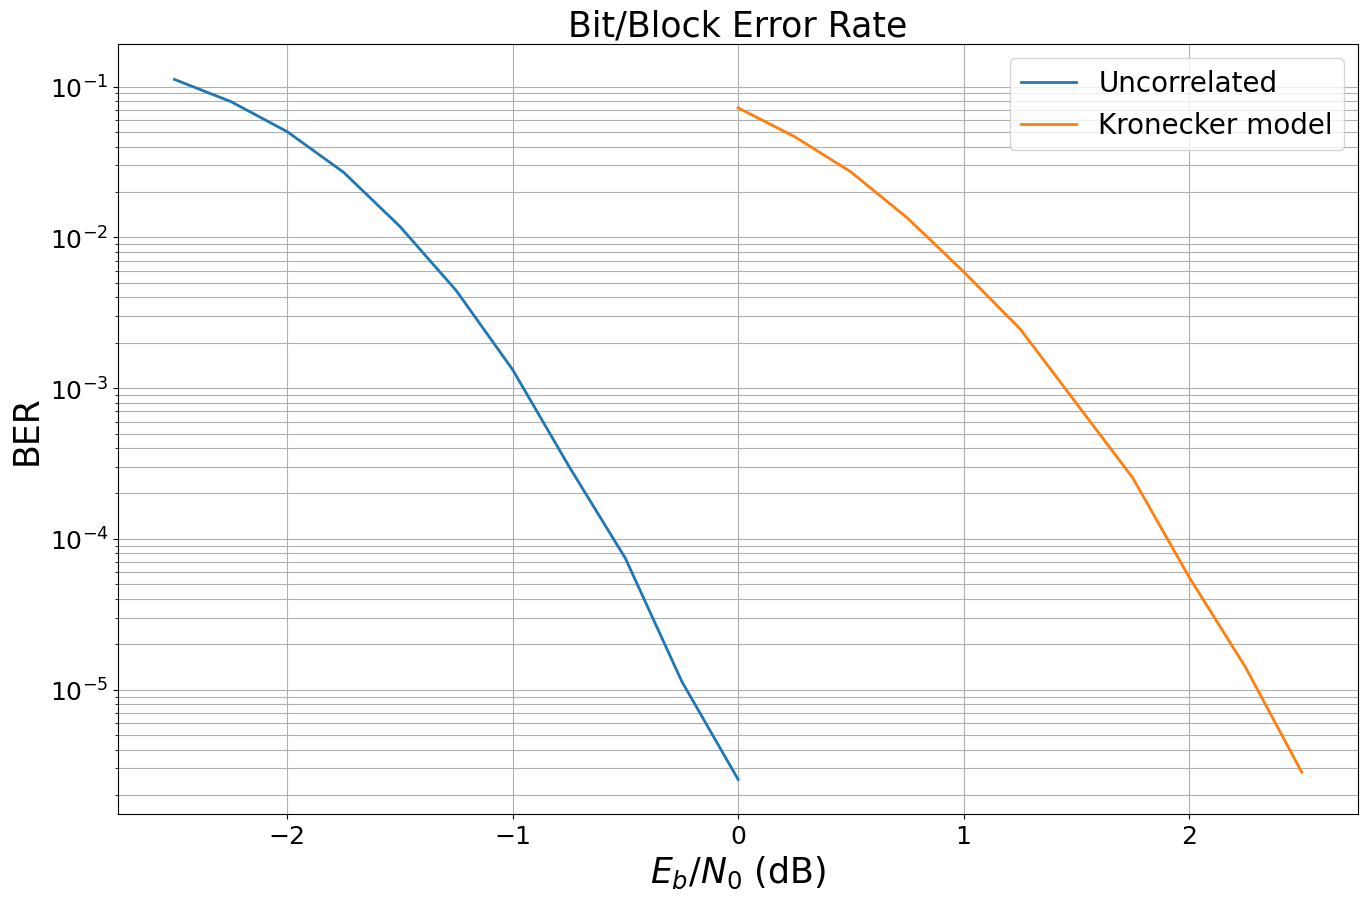

In [21]:
r_tx = exp_corr_mat(0.4, num_tx_ant)
r_rx = exp_corr_mat(0.7, num_rx_ant)
model2 = Model(KroneckerModel(r_tx, r_rx))

ber_plot.simulate(model2,
        np.arange(0,2.6,0.25),
        batch_size=4096,
        max_mc_iter=1000,
        num_target_block_errors=200,
        compile_mode="reduce-overhead",
        legend="Kronecker model");